# Sentiment Analysis on Product Reviews

### Objective
In this project, I aim to analyze customer reviews and classify them into Positive, Negative, and Neutral sentiments. This helps businesses understand customer feedback and improve their products.

### Dataset
The dataset used is Amazon Fine Food Reviews (first 5000 rows).

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from textblob import TextBlob
from wordcloud import WordCloud
import os

os.makedirs("charts", exist_ok=True)

## Data Loading
I begin by loading the dataset and selecting the first 5000 rows for analysis.

In [8]:
df = pd.read_csv("Reviews.csv")
df = df.head(5000)

df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


## Data Understanding
I explore the structure of the dataset including number of rows, columns, and data types.


In [9]:
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Id                      5000 non-null   int64 
 1   ProductId               5000 non-null   object
 2   UserId                  5000 non-null   object
 3   ProfileName             5000 non-null   object
 4   HelpfulnessNumerator    5000 non-null   int64 
 5   HelpfulnessDenominator  5000 non-null   int64 
 6   Score                   5000 non-null   int64 
 7   Time                    5000 non-null   int64 
 8   Summary                 5000 non-null   object
 9   Text                    5000 non-null   object
dtypes: int64(5), object(5)
memory usage: 390.8+ KB


## Data Cleaning
I remove null values, duplicates, and keep only relevant columns for analysis.

In [ ]:
df = df[['Text','Score']]
df = df.dropna()
df = df.drop_duplicates()
df.shape

## Feature Engineering
I create new features such as review length and word count to enhance analysis.

In [11]:
df['Review_Length'] = df['Text'].apply(len)
df['Word_Count'] = df['Text'].apply(lambda x: len(x.split()))

## Sentiment Analysis
I use TextBlob to calculate polarity scores and classify sentiment.

In [12]:
def get_sentiment(text):
    score = TextBlob(text).sentiment.polarity
    if score > 0:
        return "Positive"
    elif score < 0:
        return "Negative"
    else:
        return "Neutral"

df['Sentiment'] = df['Text'].apply(get_sentiment)
df['Polarity'] = df['Text'].apply(lambda x: TextBlob(x).sentiment.polarity)

## Data Visualization
I visualize sentiment distribution and relationships using charts.

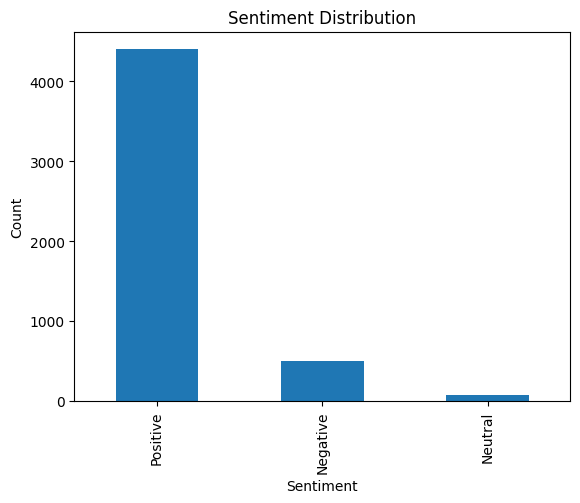

In [13]:
plt.figure()
df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.savefig("charts/bar_chart.png")
plt.show()

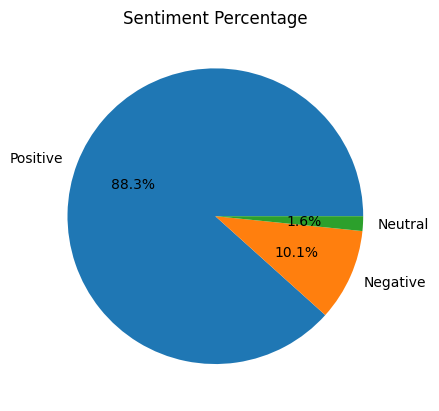

In [14]:
plt.figure()
df['Sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Sentiment Percentage")
plt.ylabel("")
plt.savefig("charts/pie_chart.png")
plt.show()

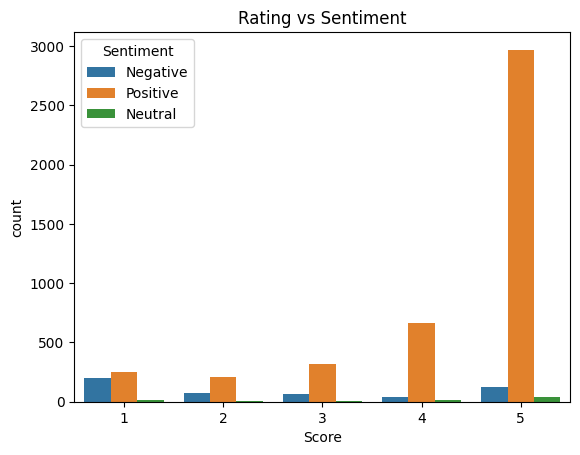

In [15]:
plt.figure()
sns.countplot(x='Score', hue='Sentiment', data=df)
plt.title("Rating vs Sentiment")
plt.savefig("charts/rating_vs_sentiment.png")
plt.show()

## Advanced Analysis
I perform deeper analysis to extract more meaningful insights.

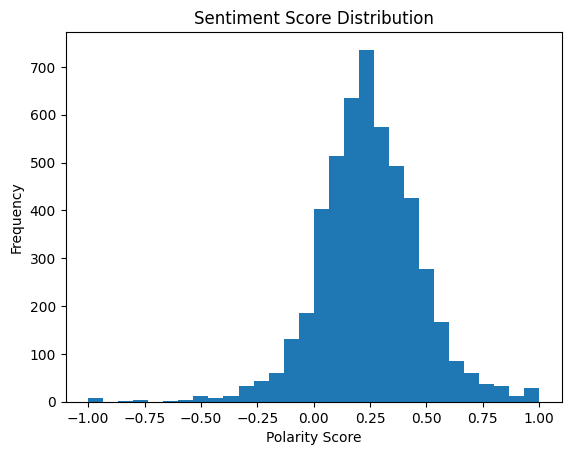

In [17]:
plt.figure()
plt.hist(df['Polarity'], bins=30)
plt.title("Sentiment Score Distribution")
plt.xlabel("Polarity Score")
plt.ylabel("Frequency")
plt.savefig("charts/polarity_distribution.png")
plt.show()

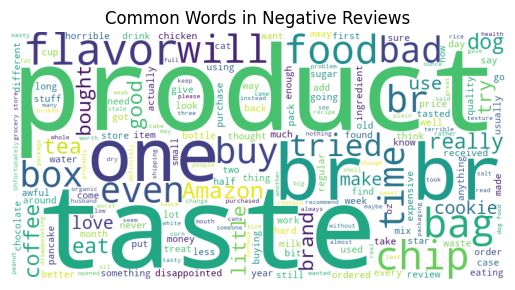

In [18]:
negative_reviews = df[df['Sentiment'] == 'Negative']

text = " ".join(negative_reviews['Text'])

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

plt.figure()
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Common Words in Negative Reviews")
plt.savefig("charts/negative_wordcloud.png")
plt.show()

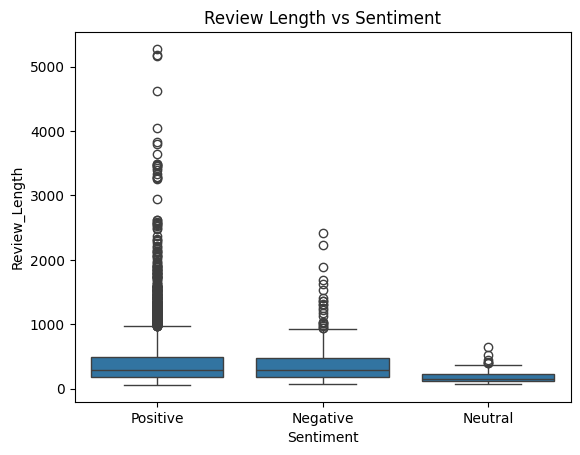

In [19]:
plt.figure()
sns.boxplot(x='Sentiment', y='Review_Length', data=df)
plt.title("Review Length vs Sentiment")
plt.savefig("charts/review_length_vs_sentiment.png")
plt.show()

In [20]:
df.groupby('Score')['Polarity'].mean()

Score
1   -0.011740
2    0.088294
3    0.162130
4    0.244881
5    0.308430
Name: Polarity, dtype: float64

### Insight Summary
This analysis provides a data-driven understanding of customer sentiment and helps identify key areas for business improvement.

## Key Insights & Business Recommendations

1. The majority of reviews are positive, indicating strong customer satisfaction.

2. Sentiment polarity increases with rating (from -0.01 at 1-star to 0.30 at 5-star), showing strong alignment between ratings and sentiment.

3. Negative reviews frequently mention issues related to product quality, taste, and packaging (as seen in the word cloud).

4. Longer reviews tend to be more detailed and are often associated with negative feedback.

5. Some reviews with moderate ratings show mixed sentiment, indicating limitations of rating-only analysis.

### Recommendations

- Improve product quality and packaging based on negative feedback  
- Use sentiment analysis for continuous monitoring  
- Focus on resolving key complaint areas to increase customer satisfaction

## Final Summary

# Sentiment Analysis on Product Reviews

### Overview

In this project, I analyzed customer reviews from the Amazon Fine Food Reviews dataset to understand customer sentiment. The objective was to classify reviews into Positive, Negative, and Neutral categories and extract meaningful business insights from the data.

### Approach

I began by loading and exploring the dataset, followed by cleaning the data by removing null values and duplicates. I focused on the relevant columns (Text and Score) for sentiment analysis.

I used the TextBlob library to calculate sentiment polarity scores and classified each review accordingly. Additionally, I performed feature engineering by creating new features such as review length and word count to enhance the analysis.

### Analysis & Visualizations

I created multiple visualizations including:

* Sentiment distribution (bar chart)
* Sentiment percentage (pie chart)
* Rating vs sentiment comparison
* Polarity distribution histogram
* Review length vs sentiment analysis
* Word cloud for negative reviews

These visualizations helped in understanding customer behavior and identifying patterns in feedback.

### Key Insights

* The majority of reviews are positive, indicating overall customer satisfaction.
* Sentiment polarity increases with higher ratings, confirming a strong relationship between rating and sentiment.
* Negative reviews frequently highlight issues related to product quality, taste, and packaging.
* Longer reviews tend to be more detailed and are often associated with negative feedback.
* Some reviews with moderate ratings show mixed sentiment, indicating nuanced customer opinions.

### Business Recommendations

* Improve product quality and packaging based on recurring negative feedback.
* Monitor customer reviews regularly using sentiment analysis for faster decision-making.
* Focus on addressing key complaint areas to improve customer satisfaction and retention.

### Conclusion

This project demonstrates how sentiment analysis can be used to transform raw customer feedback into actionable insights, enabling data-driven decision-making for businesses.

